In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("placement_new.csv")

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
975,8.43,25.0,1
81,7.12,44.0,1
90,7.61,15.0,1
255,7.76,10.0,0
705,6.55,35.0,1


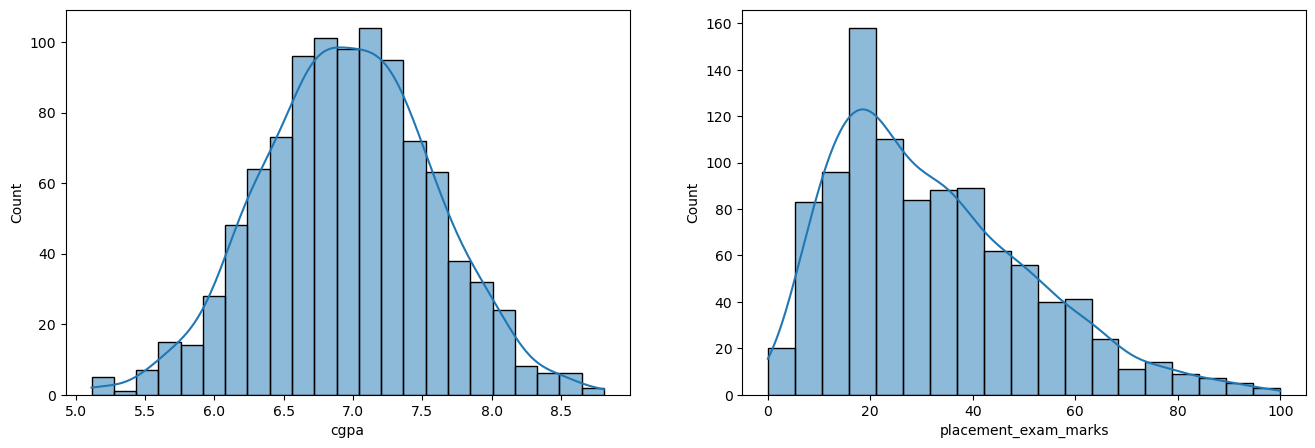

In [42]:
plt.figure(figsize=(16,5))
plt.subplot(121)

sns.histplot(data=df,x='cgpa',kde=True)

plt.subplot(122)
sns.histplot(data=df,x='placement_exam_marks',kde=True)

plt.show()

In [11]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [16]:
# Boundary Values
print("Highest allowed: ", (df['cgpa'].mean()+(3*df['cgpa'].std())))

print("Lowest allowed: ", (df['cgpa'].mean()-(3*df['cgpa'].std())))

Highest allowed:  8.808933625397168
Lowest allowed:  5.113546374602832


In [19]:
# Finding the outliers

df[(df['cgpa']> 8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [24]:
# trimming
new_df=df[(df['cgpa']<=8.80) & (df['cgpa']>=5.11)]

In [25]:
new_df.shape

(995, 3)

In [26]:
# new approach - using Z-score

df['Z_score'] = (df['cgpa']-df['cgpa'].mean())/(df['cgpa'].std())

In [29]:
df[(df['Z_score']>3) | (df['Z_score']<-3)]

,cgpa,placement_exam_marks,placed,Z_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


## Capping

In [32]:
upper_limit=df['cgpa'].mean()+(3*df['cgpa'].std())
lower_limit=df['cgpa'].mean()-(3*df['cgpa'].std())
print(upper_limit)
print(lower_limit)

8.808933625397168
5.113546374602832


In [35]:
df['cgpa']=np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [40]:
df.shape

(1000, 4)

In [41]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64